# **Exploratory Data Analysis with Pandas**

## ***Netflix Analytics: From Data Insights to Personalized Recommendations***

Author: Mubeen Akhund  
Platform: Kaggle + GitHub  
Focus: Data Cleaning, Exploration, basic Feature Enginerring, One-Hot Encoding and Understanding  

## **Project Goal**

This notebook focuses on practicing real-world data analysis using Pandas.  
The aim is not to build a machine learning model yet, but to understand the data by:

- Inspecting structure  
- Cleaning inconsistencies  
- Exploring relationships  
- Gaining intuition about the dataset  

This notebook is written as a learning-oriented EDA project.

## **Project Overview**
This notebook explores the Netflix library through 40 analytical lenses and builds a Content-Based Recommender System.

### Key Technical Highlights:

Data Cleaning: Vectorized string manipulation to handle multi-label genres and duration parsing.

EDA: Deep dives into content distribution by rating, decade, and country production.

Recommendation Logic: Implementation of a Vector Space Model (VSM) using sklearn.metrics.pairwise.cosine_similarity.

Feature Scaling: Applied Min-Max Scaling to numerical features to prevent bias in the similarity matrix.

# ***FROM BASIC TO ADVANCE (1 - 40)***
The data was cleaned wherever necessary only and rest of the things are mostly done on the Raw Dataset.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.DataFrame(pd.read_csv('netflix_titles.csv'))


Using head() method to get a first look at the dataset structure, column naming style, and basic value patterns.  
We use it to quickly verify whether the data loaded correctly.

In [3]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


Using info() method to see data types and missing values.  
From this, we identify numeric vs categorical columns and see where cleaning may be needed.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Counting the number of Null/NaN/Missing values in each column/feature.

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# ***1. How many movies and TV shows are there in the dataset?***

In [6]:
df.groupby('type')['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

# ***2. What are the top 10 countries producing the most content***

In [7]:
# Create a method which will convert the features with String values like "'abc', 'xyz', 'abc'" into a list byt first removing all extra spaces
# and duplicate values. This method will help in certain scenarios to count and check whether a particular Record refers to a multi-value column

def splitting(col_str_to_list):
    if str(col_str_to_list) == "nan":
        return np.nan
    return list (set([col_str.strip() for col_str in col_str_to_list.split(',')]))

In [8]:
Top_Countries = df['country'].apply(splitting).explode().value_counts()

In [9]:
Top_Countries

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Somalia              1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64

# ***3. How many titles were released each year?***

In [10]:
df.groupby('release_year')['title'].count()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: title, Length: 74, dtype: int64

# ***4. Which rating (PG, TV-MA, etc.) appears most frequently?***

In [11]:
df.groupby('rating')['rating'].value_counts().sort_values(ascending=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
66 min         1
84 min         1
74 min         1
Name: count, dtype: int64

In [12]:
#Checking any anomaly in 'rating' feature such as whether rating contains some unusal values or not.

df[ (df['rating'].isin ( ['66 min', '74 min', '84 min' ])) ]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


Hmmm! Looks like some columns are un-ordered (duration and rating) looks like they have been swapped in some rows

In [13]:
mask = df['rating'].str.contains('min', na=False)

In [14]:
df.loc[mask, 'duration'] = df.loc[mask,'rating']

Fixed 'duration' feature values for rows where they were swapped by assigning them their corresponding values from the rating column

In [15]:
df.loc[mask, 'rating'] = df.query("type=='Movie'")['rating'].mode()

Fixed the remaining 'rating' feature values by replacing them with the most common 'Movie' rating

In [16]:
df.groupby('rating')['rating'].value_counts().sort_values(ascending=False)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

# ***5. Find all titles that have missing director information.***

In [17]:
df [df['director'].isnull()]['title']

1                             Blood & Water
3                     Jailbirds New Orleans
4                              Kota Factory
10      Vendetta: Truth, Lies and The Mafia
14          Crime Stories: India Detectives
                       ...                 
8795                        Yu-Gi-Oh! Arc-V
8796                             Yunus Emre
8797                              Zak Storm
8800                     Zindagi Gulzar Hai
8803                            Zombie Dumb
Name: title, Length: 2634, dtype: object

# ***6. What percentage of the dataset has missing country values?***

In [18]:
(df['country'].isnull().sum() / len(df)) * 100

np.float64(9.435676166685592)

# ***7. List all titles added to Netflix in 2021.***

In [19]:
# First converting the 'date_added' feature from 'String' to 'date_time' data type

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [20]:
df.query("date_added.dt.year == 2021 ")[['title', 'date_added']]

,title,date_added
0,Dick Johnson Is Dead,2021-09-25
1,Blood & Water,2021-09-24
2,Ganglands,2021-09-24
3,Jailbirds New Orleans,2021-09-24
4,Kota Factory,2021-09-24
...,...,...
8272,The Departed,2021-01-01
8320,The Girl with the Dragon Tattoo,2021-01-05
8434,The Naked Gun: From the Files of Police Squad!,2021-01-01
8437,The Netflix Afterparty,2021-01-02


# ***8. What is the oldest release year in the dataset?***

In [21]:
print ( df['release_year'].min() )

1925


# ***9. Count how many titles belong to more than one genre.***

In [22]:
df['listed_in'] = df['listed_in'].apply(splitting)

In [23]:
masking = df['listed_in'].apply(lambda x: len(x)>1)
print(df[masking]['title'].value_counts().sum())

6787


# ***10. Which genres appear most frequently?***

In [24]:
df['listed_in'].explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

# ***11. Clean the duration column and extract:***
**1. Movie duration in minutes**

In [25]:
df.query("type=='Movie'")[['title','duration']]

,title,duration
0,Dick Johnson Is Dead,90 min
6,My Little Pony: A New Generation,91 min
7,Sankofa,125 min
9,The Starling,104 min
12,Je Suis Karl,127 min
...,...,...
8801,Zinzana,96 min
8802,Zodiac,158 min
8804,Zombieland,88 min
8805,Zoom,88 min


**2. TV show duration in number of seasons**

In [26]:
df.query("type=='TV Show'")[['title','duration']].sort_values(by='duration', ascending=False)

,title,duration
1480,Still Game,9 Seasons
6504,Club Friday The Series 6,9 Seasons
67,Saved by the Bell,9 Seasons
1998,Call the Midwife,9 Seasons
8,The Great British Baking Show,9 Seasons
...,...,...
3848,Cinta Teruna Kimchi,1 Season
3847,Cinta Si Wedding Planner,1 Season
3846,Cinta Iris,1 Season
3845,Cinta 100KG,1 Season


# ***12. Compare the average movie duration by rating.***

In [27]:
# Removing all 'min' text from 'duration' values of content type 'Movie' to create homogenousity among values to some extent.

masked = df.query("type=='Movie'")
df.loc[masked.index,'duration'] = df.loc[masked.index,'duration'].str.replace('min', '', regex=False).str.strip().astype(float)

In [28]:
subset = df.loc[masked.index]

In [29]:
subset.groupby('rating')['duration'].mean().sort_values()

rating
TV-Y         48.114504
TV-Y7         66.28777
TV-Y7-FV          68.4
TV-G         79.666667
G            90.268293
NR           94.533333
TV-PG        94.851852
TV-MA        95.889913
PG            98.28223
UR          106.333333
R           106.720201
PG-13       108.330612
TV-14        110.29082
NC-17            125.0
Name: duration, dtype: object

# ***13. Which countries produce more TV shows than movies?***

In [30]:
df['country'] = df['country'].apply(splitting)

In [31]:
counts = df.explode('country').groupby('type')['country'].value_counts()

In [32]:
type_table = counts.unstack('type', fill_value=0)

In [33]:
filtered_countries = type_table[ type_table['Movie'] > type_table['TV Show'] ]

In [34]:
filtered_countries.sort_values(by='Movie', ascending=False)

type,Movie,TV Show
country,,
United States,2752,938
India,962,84
United Kingdom,534,272
Canada,319,126
France,303,90
...,...,...
Samoa,1,0
Sri Lanka,1,0
Sudan,1,0


In [35]:
df['director'] = df['director'].apply(splitting)

# ***14. Find the top 5 directors with the most titles.***

In [36]:
df.explode('director').groupby('director')['title'].agg(counted='count').sort_values(by='counted', ascending=False).head(5)

,counted
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Marcus Raboy,16
Suhas Kadav,16


# ***15. How has Netflix content growth changed before vs after 2016?***

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [39]:
countsss = df.groupby(df['date_added'].dt.year)['title'].count()

(2008.0, 2021.0)

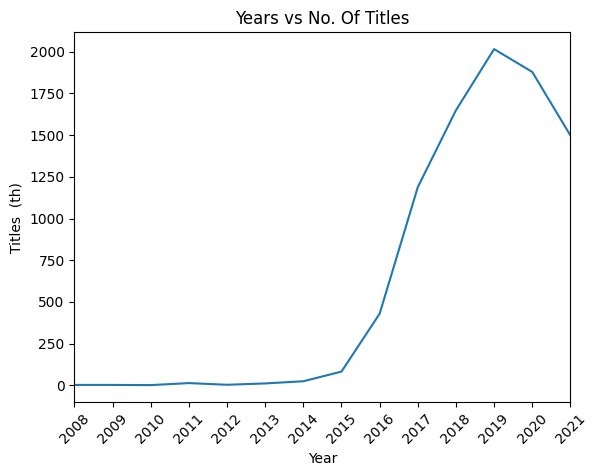

In [40]:
plt.plot(countsss.index, countsss.values)
plt.ylabel('Titles  (th)')
plt.xlabel('Year')
plt.title('Years vs No. Of Titles')
plt.xlim(2008, 2022)
plt.xticks(countsss.index, rotation=45)
plt.xlim(2008, 2021)

Looking at this graph, we can safely conclude that Netflix content additions surged exponentially after 2015, peaking in 2019, showcasing a strategic shift toward rapid library expansion and originals, while mostly remaining stagnant from 2008 uptill 2015.

# ***16. Identify genres that are:***
**Mostly movies  AND**
**Mostly TV shows**

In [41]:
df.explode('listed_in').groupby('listed_in')['type'].value_counts().unstack().fillna(0)

type,Movie,TV Show
listed_in,,
Action & Adventure,859.0,0.0
Anime Features,71.0,0.0
Anime Series,0.0,176.0
British TV Shows,0.0,253.0
Children & Family Movies,641.0,0.0
Classic & Cult TV,0.0,28.0
Classic Movies,116.0,0.0
Comedies,1674.0,0.0
Crime TV Shows,0.0,470.0


# ***17. Which year had the highest number of releases?***

In [42]:
print ( df.groupby('release_year')['title'].count().sort_values(ascending=False).head(1).index[0] )

2018


# ***18. What is the median movie duration?***

In [43]:
print ( df[ df['type'] == 'Movie']['duration'].median() )

98.0


# ***19. Which actors appear in the highest number of titles?***

In [44]:
df['cast'] = df['cast'].apply(splitting)

In [45]:
df.explode('cast').groupby('cast')['title'].count().sort_values(ascending=False)

cast
Anupam Kher               43
Shah Rukh Khan            35
Julie Tejwani             33
Takahiro Sakurai          32
Naseeruddin Shah          32
                          ..
Şevket Çoruh               1
Jamie Renée Smith          1
Şükran Ovalı               1
Malaika Wakoli-Abigaba     1
Steve Hicks                1
Name: title, Length: 36439, dtype: int64

# ***20. Create a new column: “Content Age”***

In [46]:
current_year = pd.Timestamp.now().year

df['Content Age'] = current_year - df['release_year']
df.head(4)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content Age
0,s1,Movie,Dick Johnson Is Dead,[Kirsten Johnson],NaN,[United States],2021-09-25,2020,PG-13,90.0,[Documentaries],"As her father nears the end of his life, filmm...",6
1,s2,TV Show,Blood & Water,NaN,"[Ama Qamata, Getmore Sithole, Cindy Mahlangu, ...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",5
2,s3,TV Show,Ganglands,[Julien Leclercq],"[Bakary Diombera, Geert Van Rampelberg, Noured...",NaN,2021-09-24,2021,TV-MA,1 Season,"[International TV Shows, Crime TV Shows, TV Ac...",To protect his family from a powerful drug lor...,5
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"[Reality TV, Docuseries]","Feuds, flirtations and toilet talk go down amo...",5


# ***21. Write a query to find titles where country = 'India' and type = 'Movie'***

In [47]:
df.explode('country').loc[lambda x: (x['country'] == 'India') & (x['type'] == 'Movie')].head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content Age
24,s25,Movie,Jeans,[S. Shankar],"[Aishwarya Rai Bachchan, Prashanth, Nassar, Sr...",India,2021-09-21,1998,TV-14,166.0,"[International Movies, Romantic Movies, Comedies]",When the father of the man she loves insists t...,28
29,s30,Movie,Paranoia,[Robert Luketic],"[Josh Holloway, Harrison Ford, Liam Hemsworth,...",India,2021-09-19,2013,PG-13,106.0,[Thrillers],"Blackmailed by his company's CEO, a low-level ...",13
105,s106,Movie,Angamaly Diaries,[Lijo Jose Pellissery],"[Reshma Rajan, Antony Varghese, Sarath Kumar, ...",India,2021-09-05,2017,TV-14,128.0,"[Dramas, Comedies, Action & Adventure]",After growing up amidst the gang wars of his h...,9


# ***22. Get the count of titles per rating per year***

In [48]:
df.groupby(['rating', df['release_year']])['title'].agg(title_count='count')

title_count
rating   release_year             
G        1956                    1
         1958                    1
         1964                    1
         1968                    1
         1969                    1
...                            ...
TV-Y7-FV 2016                    2
         2018                    1
UR       1974                    1
         2008                    1
         2016                    1

[437 rows x 1 columns]

# ***23. Find countries with less than 10 titles***

In [49]:
country_titles = df.explode('country').groupby('country')['title'].agg(title_num='count')

In [50]:
country_titles.query(" title_num < 10 ").index

Index(['', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Armenia',
       'Azerbaijan', 'Bahamas', 'Bangladesh', 'Belarus', 'Bermuda', 'Botswana',
       'Burkina Faso', 'Cambodia', 'Cameroon', 'Cayman Islands', 'Croatia',
       'Cuba', 'Cyprus', 'Dominican Republic', 'East Germany', 'Ecuador',
       'Ethiopia', 'Georgia', 'Ghana', 'Guatemala', 'Iran', 'Iraq', 'Jamaica',
       'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Latvia', 'Liechtenstein',
       'Lithuania', 'Malawi', 'Malta', 'Mauritius', 'Mongolia', 'Montenegro',
       'Morocco', 'Mozambique', 'Namibia', 'Nepal', 'Nicaragua', 'Palestine',
       'Panama', 'Paraguay', 'Portugal', 'Puerto Rico', 'Samoa', 'Senegal',
       'Serbia', 'Slovakia', 'Slovenia', 'Somalia', 'Soviet Union',
       'Sri Lanka', 'Sudan', 'Syria', 'Uganda', 'Ukraine', 'Vatican City',
       'Venezuela', 'Vietnam', 'West Germany', 'Zimbabwe'],
      dtype='object', name='country')

# ***24. Find directors who worked in more than one country***

In [51]:
dir_country = df.explode('director').groupby('director')['country'].agg(country_count='count')
dir_country[ dir_country['country_count']>1]['country_count'].sort_values(ascending=False)

director
Jan Suter              21
Raúl Campos            19
Jay Karas              15
Marcus Raboy           15
Cathy Garcia-Molina    13
                       ..
Yoshiyuki Momose        2
Zack Snyder             2
Zak Hilditch            2
Ziad Doueiri            2
Wes Craven              2
Name: country_count, Length: 939, dtype: int64

# ***25. Find years where TV shows > movies***

In [52]:
count_of_years = df.groupby([df['release_year'], 'type'])['type'].agg(num_of_type='count').unstack().fillna(0)

In [53]:
count_of_years[count_of_years[('num_of_type', 'TV Show')] > count_of_years[('num_of_type', 'Movie')]]

num_of_type        
type               Movie TV Show
release_year                    
1925                 0.0     1.0
2021               277.0   315.0

# ***26. Find titles whose description contains the word "family"***

In [54]:
df[ df['description'].str.contains('family') ]['title']

2                       Ganglands
12                   Je Suis Karl
28                     Dark Skies
84           Omo Ghetto: the Saga
103                Shadow Parties
                  ...            
8784         Yoko and His Friends
8786                 You Can Tutu
8787    You Can’t Fight Christmas
8788                 You Carry Me
8806                       Zubaan
Name: title, Length: 619, dtype: object

# ***27. Group titles by decade (1990s, 2000s, etc.)***

In [55]:
df.groupby( (df['release_year'] // 10) * 10 )['title'].apply(list)

release_year
1920                  [Pioneers: First Women Filmmakers*]
1940    [Five Came Back: The Reference Films, Know You...
1950    [Ujala, White Christmas, Cairo Station, Dark W...
1960    [The Guns of Navarone, My Fair Lady, Saladin, ...
1970    [Jaws, Jaws 2, Return of the Prodigal Son, FTA...
1980    [Jaws 3, Jaws: The Revenge, Blade Runner: The ...
1990    [Sankofa, Avvai Shanmughi, Jeans, Minsara Kana...
2000    [Training Day, InuYasha the Movie 2: The Castl...
2010    [Resurrection: Ertugrul, Grown Ups, Dark Skies...
2020    [Dick Johnson Is Dead, Blood & Water, Gangland...
Name: title, dtype: object

# ***28. Find the top genre per year***

In [56]:
Top_genre = df.explode('listed_in').groupby('release_year')['listed_in'].agg(top_genre_count='value_counts').sort_values(by='top_genre_count',ascending=False)

In [57]:
Top_genre.groupby('release_year').head(1)

,,top_genre_count
release_year,listed_in,
2018,International Movies,340
2017,International Movies,328
2016,International Movies,305
2019,International Movies,282
2020,International Movies,239
...,...,...
1925,TV Shows,1
1959,Dramas,1
1963,Dramas,1


# ***29. Identify duplicate titles (if any)***

In [58]:
df [df['title'].duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Content Age


# ***30. Is Netflix focusing more on TV shows over time?***

In [59]:
result = df.groupby( [df['date_added'].dt.year, 'type'] )['type'].agg(NumOfAdded = 'count').unstack().fillna(0)

In [60]:
result

NumOfAdded        
type            Movie TV Show
date_added                   
2008.0            1.0     1.0
2009.0            2.0     0.0
2010.0            1.0     0.0
2011.0           13.0     0.0
2012.0            3.0     0.0
2013.0            6.0     5.0
2014.0           19.0     5.0
2015.0           56.0    26.0
2016.0          253.0   176.0
2017.0          839.0   349.0
2018.0         1237.0   412.0
2019.0         1424.0   592.0
2020.0         1284.0   595.0
2021.0          993.0   505.0

In [61]:
# Calculating The Ratio:

result['TV_Ratio'] = result[ ('NumOfAdded', 'TV Show') ] / ( result[ ('NumOfAdded', 'Movie') ] + result[ ('NumOfAdded', 'TV Show') ] )

result

NumOfAdded          TV_Ratio
type            Movie TV Show          
date_added                             
2008.0            1.0     1.0  0.500000
2009.0            2.0     0.0  0.000000
2010.0            1.0     0.0  0.000000
2011.0           13.0     0.0  0.000000
2012.0            3.0     0.0  0.000000
2013.0            6.0     5.0  0.454545
2014.0           19.0     5.0  0.208333
2015.0           56.0    26.0  0.317073
2016.0          253.0   176.0  0.410256
2017.0          839.0   349.0  0.293771
2018.0         1237.0   412.0  0.249848
2019.0         1424.0   592.0  0.293651
2020.0         1284.0   595.0  0.316658
2021.0          993.0   505.0  0.337116

Text(0, 0.5, 'TV SHOWS Ratio (0.1 = 10%)')

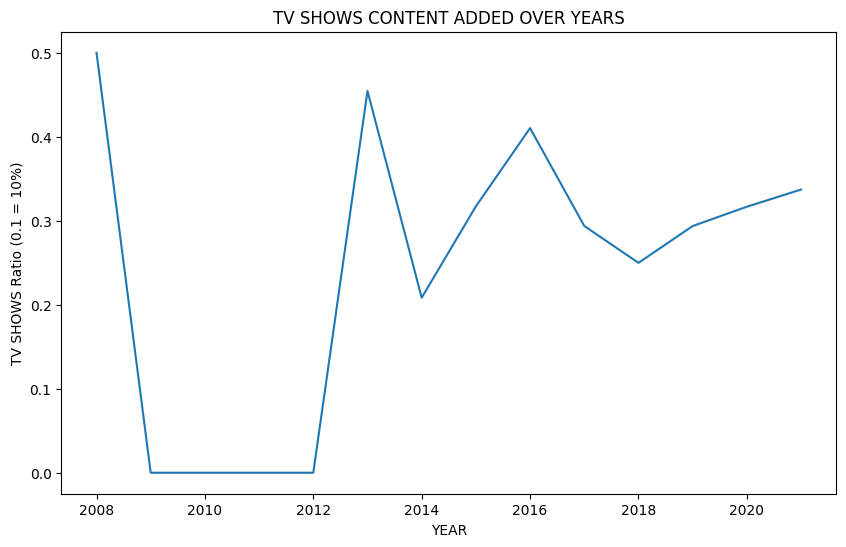

In [62]:
result['TV_Ratio'].plot(kind='line', figsize=(10,6))
plt.title("TV SHOWS CONTENT ADDED OVER YEARS")
plt.xlabel("YEAR")
plt.ylabel("TV SHOWS Ratio (0.1 = 10%)")

General for both 'Movie' and 'TV Show'
By looking at the figure above, we can Answer the Question, that over time, it fluctuated wildly in the beginning, dipped around 2018, but has shown a clear and steady increase in focus over the last 3 years.

# ***31. Do international titles have different rating distributions than US titles***

In [63]:
def label_US(country_passed):
    if not isinstance(country_passed, list): return 'UNKNOWN'
    if 'United States' in country_passed: return 'US'
    return 'INTERNATIONAL'

In [64]:
df['filtered_countries'] = df['country'].dropna().apply(label_US)

In [65]:
rating_table = df.groupby(['filtered_countries','rating'])['title'].count().unstack()

rating_table

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
filtered_countries,,,,,,,,,,,,,,
INTERNATIONAL,2,2,37,38,49,128,1433,101,1830,469,100,89,3,2
US,39,1,43,243,433,660,497,89,1101,304,127,147,2,1


In [66]:
row_totals = rating_table.sum(axis=1)

In [67]:
rating_table.div(row_totals, axis=0)*100

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
filtered_countries,,,,,,,,,,,,,,
INTERNATIONAL,0.046696,0.046696,0.86388,0.887229,1.144058,2.988559,33.457857,2.358160,42.727060,10.950269,2.334812,2.077983,0.070044,0.046696
US,1.057771,0.027122,1.16626,6.590724,11.743965,17.900732,13.479794,2.413887,29.861676,8.245186,3.444535,3.986981,0.054245,0.027122


Yes, international titles have a significantly different rating distribution compared to US titles.
International content is heavily skewed toward mature ratings, with over 75% of titles falling under TV-MA and TV-14.
In contrast, US titles show a more balanced distribution, with higher proportions of PG-13 and R-rated movies and slightly more kids-oriented content.

# ***32.  Are newer movies getting shorter or longer?***

In [68]:
movie_duration = df[ df['type'] == 'Movie' ].groupby('release_year')['duration'].mean()

Text(0, 0.5, 'Movie Duration (in Mins)')

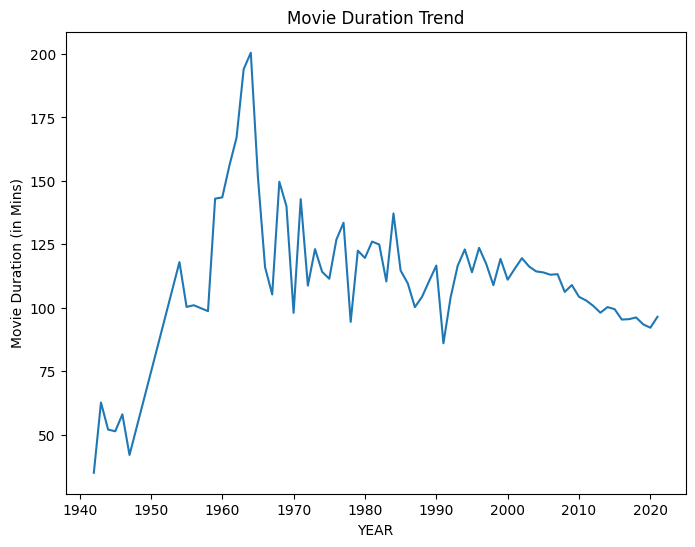

In [69]:
movie_duration.plot(kind='line', figsize=(8,6))
plt.title('Movie Duration Trend')
plt.xlabel('YEAR')
plt.ylabel('Movie Duration (in Mins)')

Looking at our above Graph, we can easily conclude that despite high volatility in early cinema, there has been a consistent and steady decline in average movie duration from the 1960s (peaking at ~200 minutes) to the modern streaming era (stabilizing under 100 minutes).

# ***33. Compare genre popularity pre-2015 vs post-2015***

In [70]:
df['PrePost_2015'] = df['release_year'].apply(lambda x: 'PRE 2015' if x<2015 else 'POST 2015')

In [71]:
compare_15 = df.explode('listed_in').groupby('PrePost_2015')['listed_in'].value_counts().unstack().fillna(0)

In [72]:
row_count = compare_15.sum(axis=1) 

In [73]:
compare_15 = compare_15.div(row_count, axis=0)*100

In [74]:
compare_15

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
PrePost_2015,,,,,,,,,,,,,,,,,,,,,
POST 2015,3.175541,0.265859,0.871428,1.469611,2.931837,0.088620,0.007385,7.000960,3.123846,0.022155,...,1.070822,3.507865,4.815006,0.516949,0.694188,0.494794,0.066465,0.391404,0.406174,2.983531
PRE 2015,7.419578,0.605327,1.003113,0.933933,4.219993,0.276721,1.988931,12.556209,0.812868,1.176064,...,0.397786,1.833276,1.919751,0.086475,0.069180,0.294016,0.121065,0.069180,0.242131,2.992044


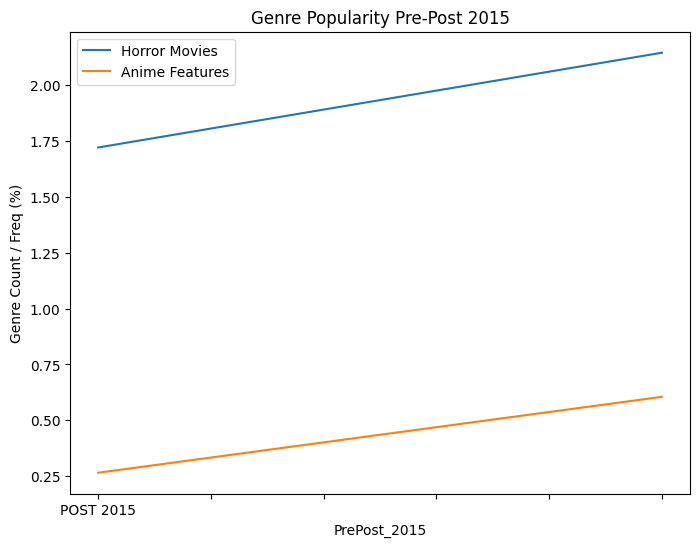

In [75]:
compare_15['Horror Movies'].plot(kind='line', figsize=(8,6))
plt.xlabel("Pre-Post Period")
plt.ylabel("Genre Count / Freq (%)")
plt.title('Genre Popularity Pre-Post 2015')
compare_15['Anime Features'].plot(kind='line', figsize=(8,6))
plt.legend()

# ***34. Which genres are country-specific?*** 

In [76]:
genre_count = df.explode('country').explode('listed_in').groupby(['listed_in'])['country'].value_counts()

In [77]:
genre_count

listed_in           country       
Action & Adventure  United States     404
                    India             137
                    United Kingdom     84
                    Hong Kong          66
                    China              63
                                     ... 
Thrillers           Serbia              1
                    Switzerland         1
                    Venezuela           1
                    Vietnam             1
                    West Germany        1
Name: count, Length: 1415, dtype: int64

In [78]:
genre_count.unstack().fillna(0).idxmax(axis=1)

listed_in
Action & Adventure               United States
Anime Features                           Japan
Anime Series                             Japan
British TV Shows                United Kingdom
Children & Family Movies         United States
Classic & Cult TV                United States
Classic Movies                   United States
Comedies                         United States
Crime TV Shows                   United States
Cult Movies                      United States
Documentaries                    United States
Docuseries                       United States
Dramas                           United States
Faith & Spirituality             United States
Horror Movies                    United States
Independent Movies               United States
International Movies                     India
International TV Shows             South Korea
Kids' TV                         United States
Korean TV Shows                    South Korea
LGBTQ Movies                     United States
Mov

# ***35. Identify content gaps (genres underrepresented in big markets)***

In [79]:
expand_table = df.explode('country').explode('listed_in')

In [80]:
mask = expand_table.groupby('country')['title'].count().sort_values(ascending=False).head(10)

In [81]:
expand_table = expand_table[ expand_table['country'].isin(mask.index) ].copy()

In [82]:
result_table = expand_table.groupby(['country', 'listed_in'])['title'].count().sort_values(ascending=False).unstack().fillna(0)

In [83]:
row_sum = result_table.sum(axis=1)

In [84]:
result_table = (result_table.div(row_sum, axis=0)*100).round(2)

In [85]:
result_table

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
Canada,5.02,0.00,0.23,0.34,9.12,0.46,0.00,10.72,1.71,0.68,...,1.37,3.42,3.65,0.91,1.03,1.03,0.00,0.57,0.23,5.59
France,4.04,0.00,0.00,0.22,2.51,0.00,0.66,5.57,2.51,0.22,...,0.66,2.62,2.95,0.33,0.22,0.11,0.00,0.33,0.00,4.80
Germany,6.46,0.00,0.00,1.17,3.33,0.00,0.00,8.22,2.94,0.78,...,0.39,0.98,3.72,0.00,0.39,0.20,0.00,0.00,0.00,5.48
India,4.89,0.00,0.00,0.11,0.93,0.00,0.39,11.52,0.32,0.18,...,0.18,0.93,1.00,0.25,0.07,0.11,0.11,0.11,0.04,3.28
Japan,7.78,8.32,19.51,0.14,2.59,0.00,0.41,1.23,2.18,0.14,...,0.68,1.36,2.86,0.68,0.55,0.00,0.14,0.82,1.91,0.68
Mexico,2.20,0.00,0.00,0.00,1.22,0.49,0.24,5.87,7.82,0.00,...,1.71,0.98,2.93,0.00,0.00,0.24,0.00,0.00,0.00,0.49
South Korea,2.69,0.00,0.00,0.00,1.58,0.00,0.00,2.69,3.80,0.16,...,1.42,3.01,6.01,0.47,0.47,0.00,0.00,0.16,0.00,2.22
Spain,1.69,0.00,0.17,0.85,1.52,0.00,0.17,7.95,4.57,0.00,...,0.68,0.85,1.86,0.00,0.00,0.00,0.00,0.00,0.17,6.43
United Kingdom,4.71,0.00,0.00,12.62,2.58,0.39,0.90,5.10,2.69,0.39,...,0.50,2.47,2.02,0.11,0.11,0.22,0.00,0.11,0.00,3.42


In [86]:
result_table.stack().groupby(level=0, group_keys=False).apply(lambda x: x.sort_values().head(3))

country         listed_in                   
Canada          Anime Features                  0.00
                Classic Movies                  0.00
                Stand-Up Comedy & Talk Shows    0.00
France          Anime Features                  0.00
                Anime Series                    0.00
                Classic & Cult TV               0.00
Germany         Anime Features                  0.00
                Anime Series                    0.00
                Classic Movies                  0.00
India           Anime Features                  0.00
                Anime Series                    0.00
                Classic & Cult TV               0.00
Japan           Classic & Cult TV               0.00
                Faith & Spirituality            0.00
                Stand-Up Comedy                 0.00
Mexico          Anime Features                  0.00
                Anime Series                    0.00
                British TV Shows                0.00
S

I stacked the normalized country–genre matrix and, within each country, sorted genres by share to extract the three least-represented ones.

# ***36. Is there a relationship between rating and duration?***

In [87]:
movies = df[ df['type']=='Movie' ].copy()

Text(0.5, 1.0, 'For Movies')

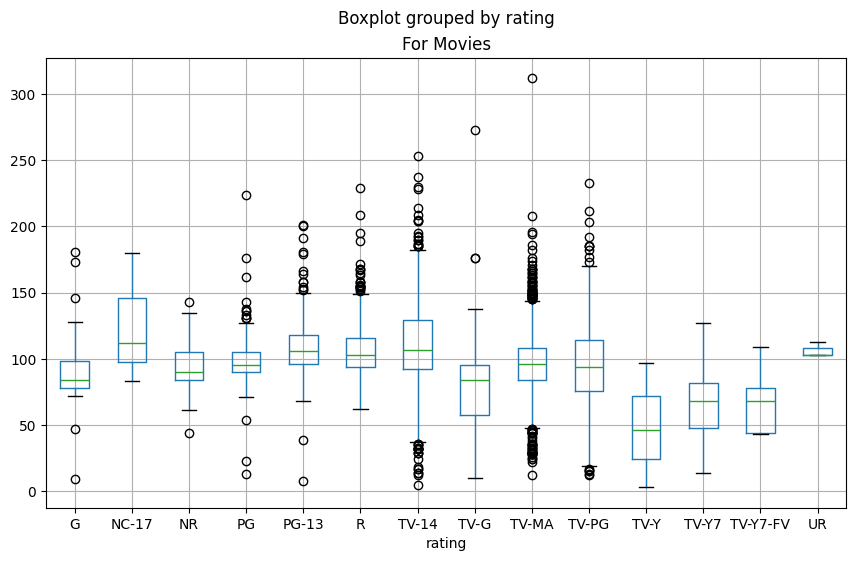

In [88]:
movies.boxplot(column='duration', by='rating', figsize=(10,6))
plt.title('For Movies')

BASED ON THE ABOVE BOXPLOT, WE CAN SAFELY CONCLUDE THE FOLLOWING THINGS:

Maturity vs. Length: There is a positive correlation between rating and duration; mature content (TV-MA, NC-17) consistently has higher median runtimes than children's programming (TV-Y, TV-Y7).

In [89]:
tv_shows = df[ df['type']=='TV Show' ].copy()

In [90]:
tv_shows['duration'] = tv_shows['duration'].str.replace('Seasons|Season', '' ,regex=True).astype(int)

Text(0.5, 1.0, 'For TV Shows')

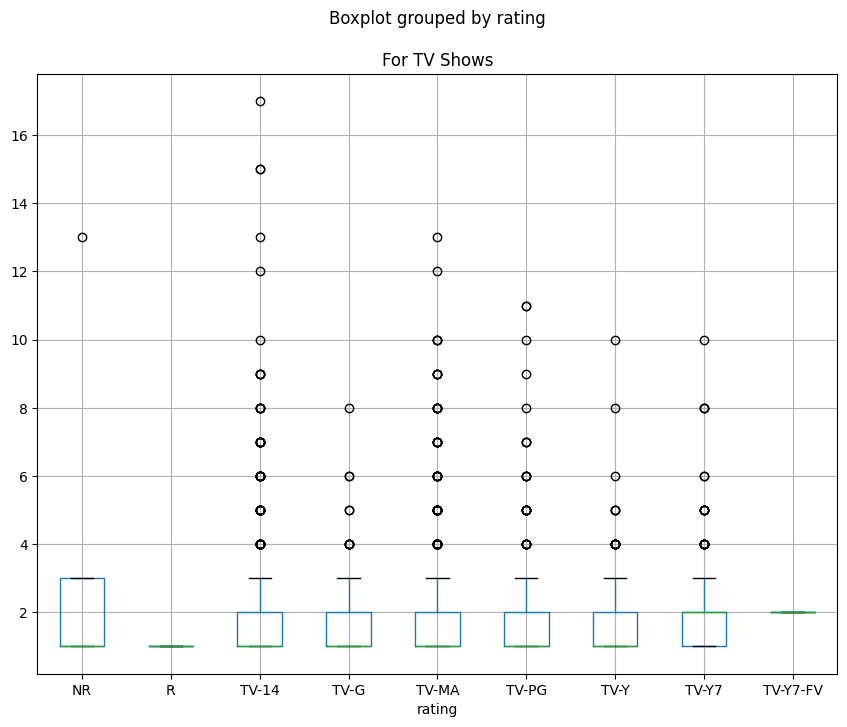

In [91]:
tv_shows.boxplot(column='duration', by='rating', figsize=(10,8))
plt.title('For TV Shows')

BASED ON THE ABOVE BOXPLOT, WE CAN CONCLUDE TWO THINGS:
1. The "Normal" Relationship: Regardless of the rating, the typical Netflix TV show is a short-term commitment of 1 to 2 seasons.
2. The "Outlier" Relationship: If a show reaches 4+ seasons, it has broken the standard mold. These outliers are much more common in TV-14 and TV-MA ratings, which suggests that mature-rated content has a better chance of becoming a "Legacy" long-running series.

# ***37. Which countries entered Netflix most recently?***

In [92]:
countries_added = df.explode('country')

In [93]:
countries_added.groupby('country')['date_added'].agg(dated='min').sort_values(by='dated',ascending=False).sort_values(by='dated')

,dated
country,
United States,2008-01-01
Denmark,2009-05-05
Spain,2011-05-17
Mexico,2011-05-17
France,2011-05-17
...,...
Bahamas,2020-08-31
Palestine,2021-04-01
Cameroon,2021-04-04


# ***38. Perform time-series analysis on content additions***

In [94]:
content_add = df.explode('listed_in').sort_values(by='date_added')

In [95]:
content_add = content_add.groupby( content_add['date_added'].dt.year )['title'].agg(content_count='count')

In [96]:
content_add

,content_count
date_added,
2008.0,4
2009.0,3
2010.0,2
2011.0,19
2012.0,4
2013.0,23
2014.0,37
2015.0,152
2016.0,858


<Axes: xlabel='date_added'>

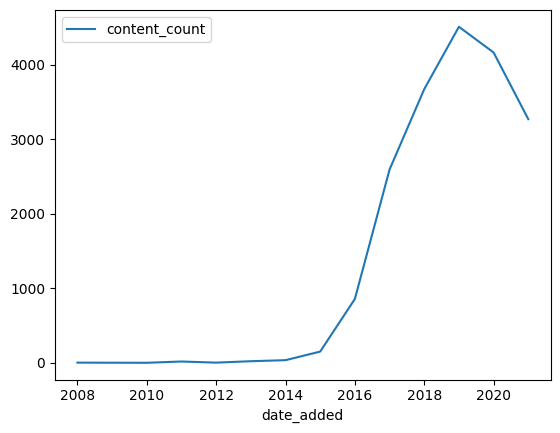

In [97]:
content_add.plot(kind='line', y='content_count')

Based on the above graph, we can safely conclude 03 points:

1. Growth Trend: Netflix transitioned from a slow-growth phase (2008–2015) into an aggressive, exponential expansion that peaked in 2019 with over 4,500 titles added.

2. Recent Decline: Since the 2019 peak, the backend logic shows a steady downward slope, indicating a slowdown in the rate of content acquisition through 2021.

3. Strategy Shift: This pattern suggests a pivot from high-volume library building to a more selective strategy, likely favoring high-quality Originals over raw quantity.

# ***Building a Content-Based Recommender System using Cosine Similarity and Feature Engineering***

In [98]:
# Creating a Feature/Column which stores number of Genres per title

df['num_genres'] = df['listed_in'].apply(lambda x: len(x))

In [99]:
# Converting the multi-label 'listed_in' text into a binary Feature Matrix.
# This process transforms the lists of 'listed_in' feature into strings again, cleans the strings, standardizes whitespaces, and performs 
# One-Hot Encoding to map each genre into a unique numerical column (feature).

genre_features = df['listed_in'].apply(lambda x: ', '.join(x)).str.strip().str.replace(r'\s+', ' ', regex=True).str.get_dummies(sep=', ')

In [100]:
# Converting the raw 'description' text into a numerical feature by calculating 
# the character count for each title. This adds a quantitative dimension 
# (description density) to the existing binary genre feature matrix.

genre_features['description_length'] = df['description'].str.len()

In [101]:
max_len = genre_features['description_length'].max()

max_len

np.int64(248)

In [102]:
# Converting the absolute character counts into a normalized scale between 0 and 1.
# This ensures the 'description_length' feature remains mathematically compatible 
# with the binary (0 or 1) genre features during similarity calculations.

genre_features['description_length'] = ( genre_features['description_length'] / max_len ) 

In [103]:
genre_features

,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers,description_length
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.612903
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0.592742
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0.588710
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.592742
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0.612903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0.604839
8803,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0.483871
8804,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.552419
8805,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.600806


In [104]:
# Converting the feature matrix into a square Similarity Matrix using Linear Algebra.
# The backend calculates the 'Cosine Similarity' between every pair of titles to 
# determine how closely their content profiles (vectors) align in 36-dimensional space.

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(genre_features)

In [105]:
# Converting the human-readable 'title' string into its unique numerical index.
# This allows the backend to pinpoint the exact row position within the 
# similarity matrix to retrieve recommendations for that specific movie.

title_idx = df[ df['title'] == 'Blood & Water'].index[0]

title_idx

np.int64(1)

In [106]:
# Converting a single row of similarity scores into a list of (index, score) pairs.
# This logic maps the raw similarity values back to their original row identifiers, 
# ensuring the backend tracks which score belongs to which movie title.

sim_scores = list(enumerate(sim_matrix[title_idx]))

In [107]:
# Converting the unsorted similarity pairs into a ranked list ordered by relevance.
# This logic uses a lambda function to target the similarity score (index 1) and 
# sorts the collection in descending order to place the most similar titles at the top.

sim_scores = sorted(sim_scores, key = lambda x: x[1], reverse=True)

In [108]:
# Converting the full ranked list into a focused subset of the Top 5 recommendations.
# This logic uses list slicing to exclude the first entry (the searched movie itself) 
# and retrieves the next five most similar titles from the sorted results.

sim_scores = sim_scores[1:6]

In [109]:
# Converting the list of numerical index pairs into human-readable movie titles.
# This loop iterates through the top matches, retrieves the corresponding row from 
# the original DataFrame using integer-location (iloc), and displays the title.

for title_tuple in sim_scores:
    title_index = title_tuple[0]
    print(df.iloc[title_index]['title'])

To the Lake
The School Nurse Files
We Are the Wave
Re:Mind
The Rain


FINAL LOGIC WRAPPED IN A FUNCTION:

In [110]:
data_table = df
similarity_matrix = sim_matrix

def recommend_me(content_title):
    if content_title in data_table['title'].values:
        content_idx = data_table[ data_table['title'] == content_title].index[0]
        similarity_score = list(enumerate(similarity_matrix[content_idx]))
        similarity_score = sorted(sim_scores, key = lambda x: x[1], reverse=True)
        similarity_score = similarity_score[1:6]
        print("Here are the similar cotent which u can watch :)\n")
        for title_tuple in sim_scores:
            content_index = title_tuple[0]
            print(data_table.iloc[content_index]['title'])
    else:
        print("Sorry! We don't have much info about that to recommend u something!")

In [111]:
# TESTING THE FUNCTIONALITY !

recommend_me('Ganglands')

Here are the similar cotent which u can watch :)

To the Lake
The School Nurse Files
We Are the Wave
Re:Mind
The Rain


# ***CONCLUSION***

This project marks a significant milestone in my journey as a Data Scientist, representing a transition from foundational Python programming to the practical implementation of machine learning concepts. Moving beyond basic data manipulation, I have applied Feature Engineering and Linear Algebra to transform a static dataset into a functional, automated recommendation engine. This experience has deepened my technical understanding of how backend mathematical logic can be harnessed to solve complex real-world challenges like content discovery.

## KEY INSIGHTS FROM MY NOTEBOOK AND ANALYSIS:

### Strategic Data Insights: 
My exploratory analysis reveals that Netflix’s library has grown exponentially since 2015, with a clear focus on mature-rated international content. A key statistical takeaway is that adult-oriented content (TV-MA) maintains a significantly higher median duration than children's programming, which follows a much more standardized, shorter runtime.

### The Logic of Vectorization:
 At the backend, I converted raw multi-label text into a Binary Feature Matrix. By performing One-Hot Encoding on genres and Normalizing description lengths, I transformed descriptive attributes into high-dimensional Feature Vectors. This allows the computer to process content not as text, but as numerical coordinates in a 36-dimensional space.

### Algorithmic Accuracy:
 By implementing Cosine Similarity, the engine moves beyond simple keyword matching. It calculates the mathematical "angular distance" between vectors to pinpoint the "Nearest Neighbors" for any given title. This ensures that the final Top 5 recommendations are mathematically aligned with the user's initial selection, providing a scalable and efficient retrieval system.

## **Future Improvements**

Incorporate TF-IDF embeddings of descriptions

Weight genre similarity vs textual similarity

Evaluate recommendations using user interaction data (if available)

# ***THANK YOU!***